 LunaCura AI: Cross-Domain Anomaly Detection using Deep Convolutional Autoencoders

# 1. Problem Definition

## Task: Unsupervised Representation Learning for Anomaly Detection

The task is to build an anomaly detection system based on unsupervised representation learning using a Convolutional Autoencoder. The core idea is to train a model to learn a compressed, efficient representation of 'normal' data. When presented with 'anomalous' data, the model's inability to accurately reconstruct it will serve as an indicator of an anomaly.

### Data Analogy:
*   **MNIST digits:** Will serve as our 'Normal Healthy Vitals'. These are the patterns the autoencoder will be trained to understand and reconstruct perfectly. Each digit represents a stable, expected biological signal or sensor reading.
*   **CIFAR-10 / Noisy MNIST:** Will represent 'System Anomalies'. CIFAR-10 images (e.g., animals, vehicles) are structurally different from MNIST digits, simulating unexpected patterns. Noisy MNIST could represent corrupted sensor data or slight deviations from baseline.

### Real-World Relevance:
This methodology has significant real-world applications, particularly in healthcare and predictive maintenance:

1.  **Medical Sensor Data Corruption:** Imagine a wearable device monitoring a patient's vital signs (e.g., ECG, EEG). If the sensor itself malfunctions or interference corrupts the data stream, the autoencoder, trained on clean, normal vital signs, would produce a high reconstruction error for the corrupted input, immediately alerting medical staff to a potential sensor issue.
2.  **Patient Biological Signal Deviation:** Each patient has a baseline of 'normal' biological signals. An autoencoder trained on an individual patient's healthy baseline can detect when their biological signal (e.g., heart rhythm, glucose levels represented as a temporal pattern) deviates significantly. This deviation could indicate the onset of a medical condition, allowing for early intervention.

By learning the underlying structure of normal data, the autoencoder provides a powerful, generalizable method for identifying deviations without requiring explicit labels for all possible anomaly types.

# 2. Mathematical Modeling

## Undercomplete Autoencoder Architecture

An Undercomplete Autoencoder consists of two main parts: an Encoder and a Decoder. The 'undercomplete' aspect implies that the latent representation (bottleneck) has a lower dimensionality than the input data, forcing the encoder to learn the most salient features of the data.

### Encoder ($f_\theta$)

The Encoder maps the input data $x$ to a lower-dimensional latent representation $h$. For 2D-Convolutional networks, this involves a series of convolutional layers, potentially with pooling or striding to reduce spatial dimensions.

Given an input image $X \in \mathbb{R}^{H \times W \times C_{in}}$, a convolutional layer $k$ with filter $W_k \in \mathbb{R}^{h_k \times w_k \times C_{in} \times C_{out}}$ and bias $b_k \in \mathbb{R}^{C_{out}}$ applies a convolution operation:

$$ f_\theta(X)_{i,j,c'} = \sigma \left( \sum_{p=0}^{h_k-1} \sum_{q=0}^{w_k-1} \sum_{c=0}^{C_{in}-1} X_{i \cdot s_x + p, j \cdot s_y + q, c} \cdot W_{k;p,q,c,c'} + b_{k;c'} \right) $$

Where:
*   $(i,j)$ are output spatial coordinates.
*   $s_x, s_y$ are strides.
*   $\sigma$ is the activation function (e.g., ReLU).
*   $h$ is the compressed latent representation, the output of the final encoder layer, potentially after a global pooling operation.

### Decoder ($g_\phi$)

The Decoder reconstructs the input data $\hat{x}$ from the latent representation $h$. For convolutional autoencoders, this is typically achieved using `Conv2DTranspose` (also known as deconvolution or fractional-strided convolution) layers, which perform upsampling.

Given a latent representation $h \in \mathbb{R}^{D}$ (after reshaping if from global pooling) or $H_L \times W_L \times C_L$ (if directly from a Conv layer), a `Conv2DTranspose` layer $k'$ with filter $W_{k'} \in \mathbb{R}^{h_{k'} \times w_{k'} \times C_{in}' \times C_{out}'}$ and bias $b_{k'} \in \mathbb{R}^{C_{out}'}$ effectively reverses the convolution:

$$ g_\phi(h)_{i',j',c'} = \sigma' \left( \sum_{p=0}^{h_{k'}-1} \sum_{q=0}^{w_{k'}-1} \sum_{c=0}^{C_{in}'-1} h_{i'_s+p, j'_s+q, c} \cdot W_{k';p,q,c,c'} + b_{k';c'} \right) $$

Where:
*   $(i',j')$ are output spatial coordinates (larger than input).
*   $i'_s = \lfloor i' / s_x \rfloor$, $j'_s = \lfloor j' / s_y \rfloor$.
*   $\sigma'$ is the activation function (e.g., ReLU for intermediate layers, Sigmoid for final output to match [0,1] input).

### Loss Function

The objective of the autoencoder is to minimize the difference between the input $x$ and its reconstruction $\hat{x} = g_\phi(f_\theta(x))$. We use the Mean Squared Error (MSE) for this purpose, combined with L2 Regularization on the weights to prevent overfitting.

$$ L(x, \hat{x}) = \text{MSE}(x, \hat{x}) + \lambda \sum \|w\|^2 $$

Where:
*   $\text{MSE}(x, \hat{x}) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2$ is the Mean Squared Error between the input and reconstructed output.
*   $\lambda$ is the L2 regularization coefficient (hyperparameter, e.g., 0.01).
*   $\sum \|w\|^2$ is the sum of the squared values of all weights $w$ in the model's layers. This term penalizes large weights, promoting simpler models and reducing overfitting (Unit 2 requirement).

### Reconstruction Error Threshold Logic for Anomaly Detection

After training the autoencoder on 'normal' data (MNIST digits), we observe the distribution of reconstruction errors (MSE values) for these normal inputs. Anomalies are detected based on the premise that the autoencoder will produce a significantly higher reconstruction error for data points that deviate from the normal patterns it was trained on.

1.  **Calculate Reconstruction Error:** For any given input image, the model produces a reconstructed image. The reconstruction error is the Mean Squared Error (MSE) between the input and its reconstruction.
2.  **Establish Threshold:** During the training and validation phase, we calculate the reconstruction error for many 'normal' inputs. A threshold is then determined, often as a percentile (e.g., 95th or 99th percentile) of the reconstruction errors of the normal training/validation set, or based on the mean plus a few standard deviations. Inputs with an MSE above this threshold are classified as anomalies.
3.  **Anomaly Classification:**
    *   If $MSE(x, \hat{x}) \le \text{Threshold}$: The input is considered **Normal**.
    *   If $MSE(x, \hat{x}) > \text{Threshold}$: The input is considered **Anomalous**.

This thresholding mechanism allows the autoencoder to differentiate between data it understands well (low error) and data it struggles to reconstruct (high error), indicating an out-of-distribution or anomalous input.

# 3. Model Design & Implementation

## Setup and Data Loading

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

# Install Gradio for the UI (if not already installed)
try:
    import gradio as gr
except ImportError:
    !pip install gradio --quiet
    import gradio as gr

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print(f"Gradio Version: {gr.__version__}")

TensorFlow Version: 2.19.0
Keras Version: 3.13.2
Gradio Version: 5.50.0


## Data Preprocessing (Normalization and Reshaping)

In [2]:
# Load MNIST dataset (Normal Data)
(x_train_mnist, _), (x_test_mnist, _) = keras.datasets.mnist.load_data()

# Normalize and reshape for CNN (28x28x1)
x_train_mnist = x_train_mnist.astype('float32') / 255.
x_test_mnist = x_test_mnist.astype('float32') / 255.
x_train_mnist = np.expand_dims(x_train_mnist, -1) # Add channel dimension
x_test_mnist = np.expand_dims(x_test_mnist, -1)

print(f"MNIST x_train shape: {x_train_mnist.shape}")
print(f"MNIST x_test shape: {x_test_mnist.shape}")

# Load CIFAR-10 dataset (Anomalous Data)
(x_train_cifar, _), (x_test_cifar, _) = keras.datasets.cifar10.load_data()

# Preprocess CIFAR-10 for anomaly detection:
# 1. Convert to grayscale
# 2. Resize to 28x28 to match MNIST input dimensions
# 3. Normalize

def preprocess_cifar_for_anomaly(images):
    # Convert to grayscale: Average across color channels
    images_gray = np.mean(images, axis=-1)
    # Resize to 28x28 (using TensorFlow for convenience)
    images_resized = tf.image.resize(
        np.expand_dims(images_gray, -1),  # Add channel dim for resize
        (28, 28),
        method=tf.image.ResizeMethod.BILINEAR
    ).numpy()
    # Normalize
    return images_resized.astype('float32') / 255.

x_train_cifar_processed = preprocess_cifar_for_anomaly(x_train_cifar)
x_test_cifar_processed = preprocess_cifar_for_anomaly(x_test_cifar)

print(f"CIFAR-10 processed x_train shape: {x_train_cifar_processed.shape}")
print(f"CIFAR-10 processed x_test shape: {x_test_cifar_processed.shape}")

MNIST x_train shape: (60000, 28, 28, 1)
MNIST x_test shape: (10000, 28, 28, 1)
CIFAR-10 processed x_train shape: (50000, 28, 28, 1)
CIFAR-10 processed x_test shape: (10000, 28, 28, 1)


## Deep Convolutional Autoencoder Architecture

This section implements the CNN Autoencoder as specified:
*   **Encoder:** 3x Conv2D layers with ReLU, Dropout, and L2 regularization.
*   **Bottleneck:** `GlobalMaxPooling2D` followed by a `Dense` layer and `Reshape`.
*   **Decoder:** 3x Conv2DTranspose layers to reconstruct the 28x28 image.

In [3]:
# Input shape for MNIST images
input_shape = (28, 28, 1)
l2_lambda = 0.01 # L2 Regularization coefficient
dropout_rate = 0.2 # Dropout rate

# Encoder
encoder_input = keras.Input(shape=input_shape, name='encoder_input')
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(l2_lambda), name='enc_conv_1')(encoder_input)
x = layers.Dropout(dropout_rate, name='enc_dropout_1')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=(2, 2), kernel_regularizer=regularizers.l2(l2_lambda), name='enc_conv_2')(x)
x = layers.Dropout(dropout_rate, name='enc_dropout_2')(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', strides=(2, 2), kernel_regularizer=regularizers.l2(l2_lambda), name='enc_conv_3')(x)
x = layers.Dropout(dropout_rate, name='enc_dropout_3')(x)

# Bottleneck
# Calculate dimensions after encoder layers to reshape correctly for decoder
# (28,28) -> (14,14) after stride 2 -> (7,7) after stride 2
# Latent space is a flattened vector from GlobalMaxPooling2D
shape_before_flattening = keras.backend.int_shape(x)[1:] # e.g., (7, 7, 128)
latent_vector = layers.GlobalMaxPooling2D(name='bottleneck')(x)

# Decoder (Autoencoders - using Conv2DTranspose for upsampling)
# Need to reshape the latent vector back to a spatial representation
decoder_input = keras.Input(shape=(latent_vector.shape[1],), name='decoder_input')

# The starting point for the Conv2DTranspose layers should be a spatial representation
# We multiply the height * width * channels from the last Conv2D layer before GlobalMaxPooling
y = layers.Dense(shape_before_flattening[0] * shape_before_flattening[1] * shape_before_flattening[2], activation='relu', name='dec_dense')(decoder_input)
y = layers.Reshape(shape_before_flattening, name='dec_reshape')(y)

y = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(l2_lambda), name='dec_convT_1')(y)
y = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=(2, 2), kernel_regularizer=regularizers.l2(l2_lambda), name='dec_convT_2')(y)
y = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=(2, 2), kernel_regularizer=regularizers.l2(l2_lambda), name='dec_convT_3')(y)
decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoder_output')(y) # Output 28x28x1 image

# Build the Encoder Model
encoder_model = keras.Model(encoder_input, latent_vector, name='encoder')

# Build the Decoder Model
decoder_model = keras.Model(decoder_input, decoder_output, name='decoder')

# Build the Autoencoder Model
autoencoder_output = decoder_model(encoder_model(encoder_input))
autoencoder = keras.Model(encoder_input, autoencoder_output, name='conv_autoencoder')

autoencoder.compile(optimizer='adam', loss='mse')

print("Autoencoder Summary:")
autoencoder.summary()

print("\nEncoder Summary:")
encoder_model.summary()

print("\nDecoder Summary:")
decoder_model.summary()

Autoencoder Summary:


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 128)            │        92,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │     1,049,217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,141,889 (4.36 MB)

 Trainable params: 1,141,889 (4.36 MB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_reshape (Reshape)           │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_convT_1 (Conv2DTranspose)   │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_convT_2 (Conv2DTranspose)   │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_convT_3 (Conv2DTranspose)   │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,049,217 (4.00 MB)

 Trainable params: 1,049,217 (4.00 MB)

 Non-trainable params: 0 (0.00 B)

---

# 4. Model Training & Evaluation

Training the Autoencoder -Training is performed using the 'normal' MNIST data. Early Stopping is applied to prevent overfitting and optimize training time (Unit 2).

In [4]:
# Early Stopping (Unit 2)
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5, # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Train the autoencoder on normal MNIST data
history = autoencoder.fit(
    x_train_mnist,
    x_train_mnist,
    epochs=50, # Can be increased, EarlyStopping will manage it
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_mnist, x_test_mnist),
    callbacks=[early_stopping_callback]
)

# Evaluate the model on the test set
loss = autoencoder.evaluate(x_test_mnist, x_test_mnist, verbose=0)
print(f"Test Loss (MSE): {loss:.4f}")

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - loss: 0.2309 - val_loss: 0.0730
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0708 - val_loss: 0.0713
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0698 - val_loss: 0.0708
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0694 - val_loss: 0.0700
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0693 - val_loss: 0.0701
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0690 - val_loss: 0.0692
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0689 - val_loss: 0.0697
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0688 - val_loss: 0.0696
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0688 - val_loss: 0.0694
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0690 - val_loss: 0.0691
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0686 - val_loss: 0.0712
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━

## Plotting Training History

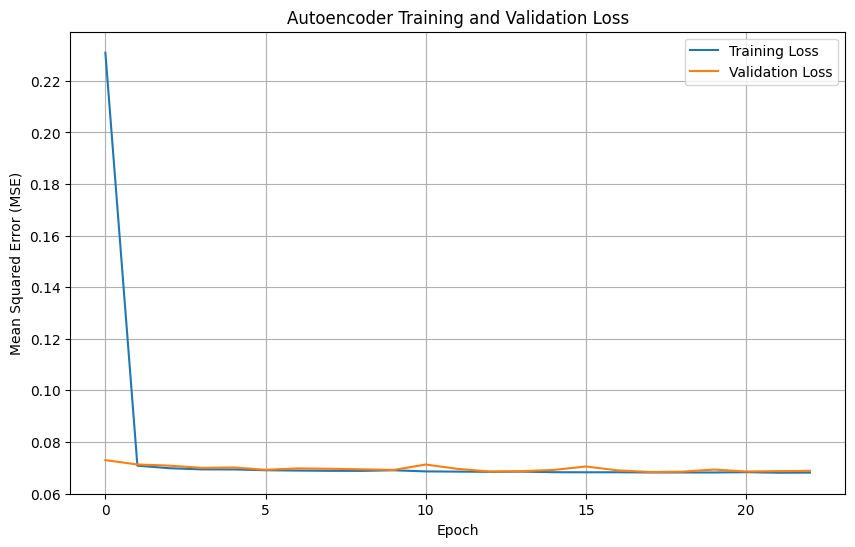

In [5]:
# Plot Training Loss vs. Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## Anomaly Detection Threshold Calculation
 calculating the reconstruction error for the normal test set (MNIST) and use its mean + standard deviation to set a threshold for anomaly detection.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Mean MSE for normal MNIST: 0.0679
Std Dev MSE for normal MNIST: 0.0181
Anomaly Threshold (Mean + 3*StdDev): 0.1221


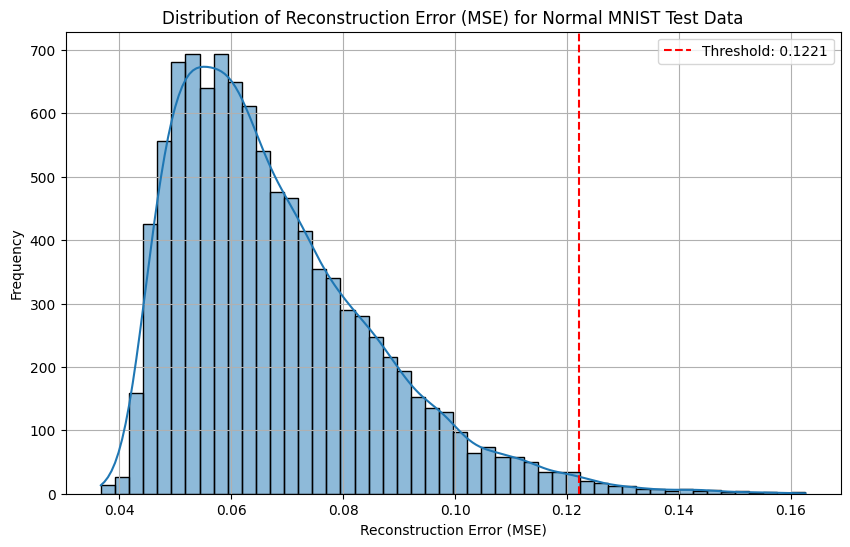

In [8]:
# Get reconstructions for normal test data
reconstructions_mnist = autoencoder.predict(x_test_mnist)

# Calculate MSE for normal test data
mse_mnist = np.mean(np.square(x_test_mnist - reconstructions_mnist), axis=(1, 2, 3))

# Determine a threshold for anomaly detection
# A common approach is mean + 2 or 3 standard deviations of normal MSE
threshold = np.mean(mse_mnist) + 3 * np.std(mse_mnist)
print(f"Mean MSE for normal MNIST: {np.mean(mse_mnist):.4f}")
print(f"Std Dev MSE for normal MNIST: {np.std(mse_mnist):.4f}")
print(f"Anomaly Threshold (Mean + 3*StdDev): {threshold:.4f}")

# Plot distribution of MSE for normal data
plt.figure(figsize=(10, 6))
sns.histplot(mse_mnist, bins=50, kde=True)
plt.axvline(threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.title('Distribution of Reconstruction Error (MSE) for Normal MNIST Test Data')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

## "Success vs. Failure" Visualization

This visualization shows how well the autoencoder reconstructs 'normal' MNIST digits versus its 'failure' to reconstruct 'anomalous' CIFAR-10 images (which appear as noise to the autoencoder).

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


/tmp/ipykernel_8823/3227422015.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.95, 1, 1])


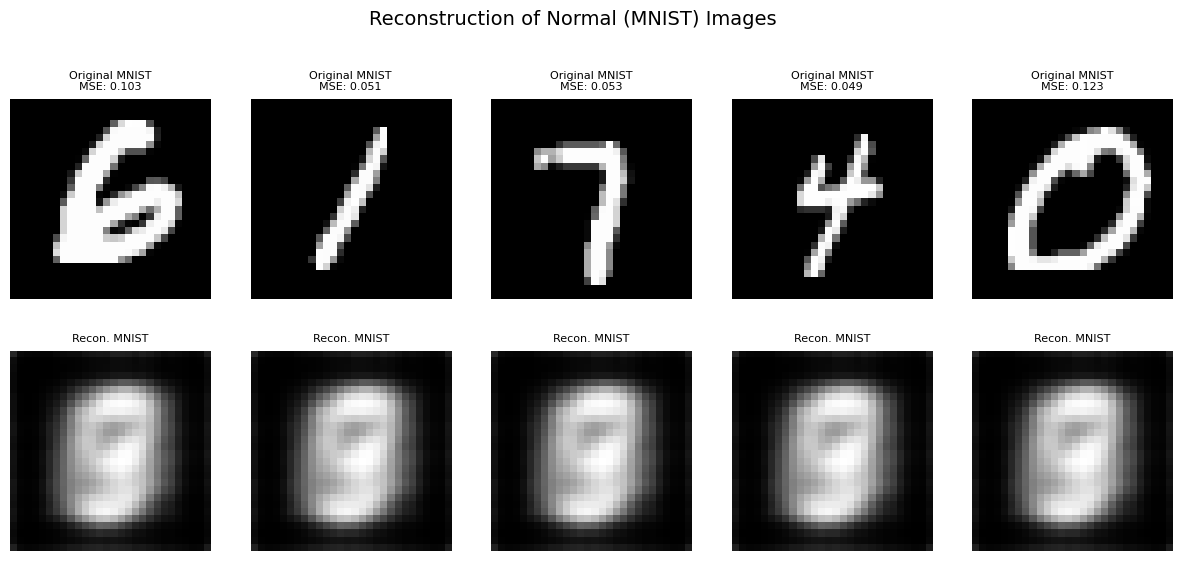

/tmp/ipykernel_8823/3227422015.py:54: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.95, 1, 1])


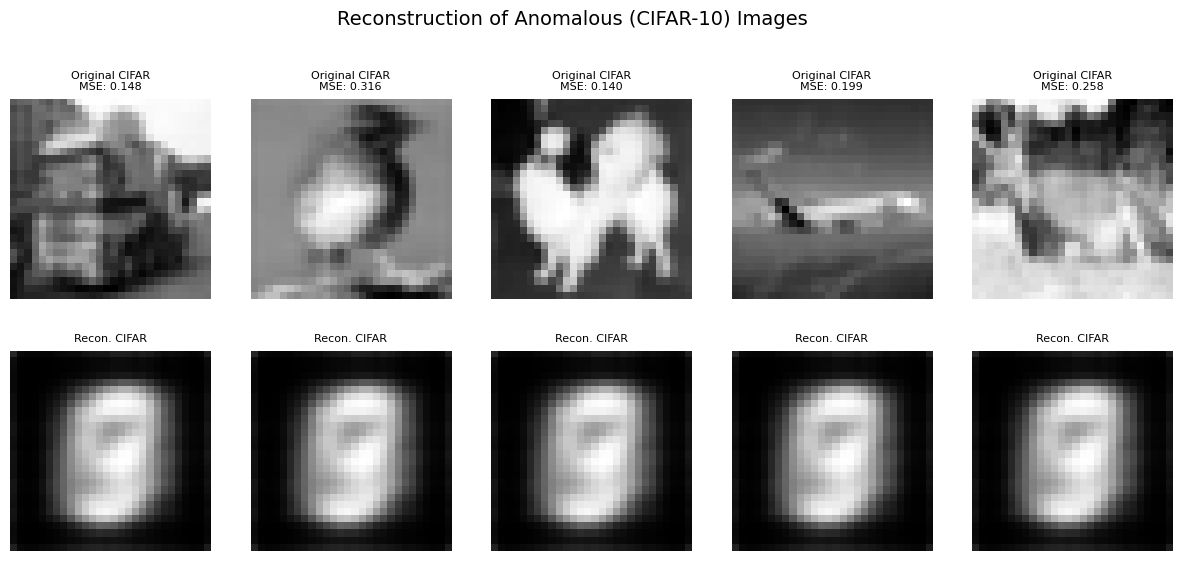

In [7]:
import seaborn as sns

# Select a few random MNIST (normal) images
n_normal_examples = 5
normal_indices = np.random.choice(len(x_test_mnist), n_normal_examples, replace=False)
normal_images = x_test_mnist[normal_indices]
normal_reconstructions = autoencoder.predict(normal_images)
normal_mse = np.mean(np.square(normal_images - normal_reconstructions), axis=(1, 2, 3))

# Select a few random CIFAR-10 (anomalous) images
n_anomaly_examples = 5
anomaly_indices = np.random.choice(len(x_test_cifar_processed), n_anomaly_examples, replace=False)
anomaly_images = x_test_cifar_processed[anomaly_indices]
anomaly_reconstructions = autoencoder.predict(anomaly_images)
anomaly_mse = np.mean(np.square(anomaly_images - anomaly_reconstructions), axis=(1, 2, 3))

plt.figure(figsize=(15, 6))

# Plot Normal Examples
for i in range(n_normal_examples):
    # Original Normal
    ax = plt.subplot(2, n_normal_examples, i + 1)
    plt.imshow(normal_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Original MNIST\nMSE: {normal_mse[i]:.3f}", fontsize=8)
    plt.axis('off')

    # Reconstructed Normal
    ax = plt.subplot(2, n_normal_examples, i + 1 + n_normal_examples)
    plt.imshow(normal_reconstructions[i].reshape(28, 28), cmap='gray')
    plt.title(f"Recon. MNIST", fontsize=8)
    plt.axis('off')

plt.suptitle('Reconstruction of Normal (MNIST) Images', y=1.02, fontsize=14)
plt.tight_layout(rect=[0, 0.95, 1, 1])
plt.show()

plt.figure(figsize=(15, 6))

# Plot Anomalous Examples
for i in range(n_anomaly_examples):
    # Original Anomaly
    ax = plt.subplot(2, n_anomaly_examples, i + 1)
    plt.imshow(anomaly_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Original CIFAR\nMSE: {anomaly_mse[i]:.3f}", fontsize=8)
    plt.axis('off')

    # Reconstructed Anomaly
    ax = plt.subplot(2, n_anomaly_examples, i + 1 + n_anomaly_examples)
    plt.imshow(anomaly_reconstructions[i].reshape(28, 28), cmap='gray')
    plt.title(f"Recon. CIFAR", fontsize=8)
    plt.axis('off')

plt.suptitle('Reconstruction of Anomalous (CIFAR-10) Images', y=1.02, fontsize=14)
plt.tight_layout(rect=[0, 0.95, 1, 1])
plt.show()

# 5. User Interface

## Gradio Web Interface
allows users to draw an image on a sketchpad or upload an image. The model then reconstructs it, calculates the MSE, and classifies it as "Normal" or "Anomaly" based on the calculated threshold.

In [ ]:

import gradio as gr
gr.close_all()

interface.launch(
    inline=True,
    share=False,
    prevent_thread_lock=True
)

In [9]:
def predict_anomaly(input_img, threshold):
    if input_img is None:
        return None, 0.0, "Please provide an image."

    if isinstance(input_img, str):
        from PIL import Image
        input_img = np.array(Image.open(input_img).convert('L')) # Convert to grayscale

    # Preprocess the input image to match model's expected input (28x28x1, normalized)
    img_processed = tf.image.resize(np.expand_dims(input_img, -1), (28, 28), method=tf.image.ResizeMethod.BILINEAR).numpy()
    img_processed = img_processed.astype('float32') / 255.
    img_processed = np.expand_dims(img_processed, axis=0) # Add batch dimension

    # Get reconstruction
    reconstructed_img = autoencoder.predict(img_processed)

    # Calculate MSE
    mse = np.mean(np.square(img_processed - reconstructed_img))

    # Determine status
    status = "Anomaly Detected" if mse > threshold else "Signal Stable"

    # Reshape reconstructed image for Gradio output
    reconstructed_img_display = (reconstructed_img.squeeze() * 255).astype(np.uint8)

    return reconstructed_img_display, float(f'{mse:.4f}'), status

# Interface components
image_input = gr.Image(image_mode='L', label="Draw a digit or upload an image") # Removed source and tool
image_output = gr.Image(image_mode='L', label="Model Reconstruction")
mse_output = gr.Textbox(label="Reconstruction Error (MSE)")
status_output = gr.Label(label="Status")

# Create the Gradio interface
iface = gr.Interface(
    fn=lambda img: predict_anomaly(img, threshold), # Pass the calculated threshold
    inputs=image_input,
    outputs=[image_output, mse_output, status_output],
    title="LunaCura AI: Deep-Vision Anomaly Detector",
    description=f"Draw a digit (Normal) or upload an image (Anomaly) to test the Autoencoder. "
                f"The model is trained on MNIST digits. Anomalies are detected if MSE > {threshold:.4f}.",
    allow_flagging="never"
    # Removed examples argument to prevent 403 error
)

# Launch the interface
iface.launch(debug=True, share=True) # share=True for public link in Colab

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6e640638e3a1fec1e7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6e640638e3a1fec1e7.gradio.live


Processing MNIST...


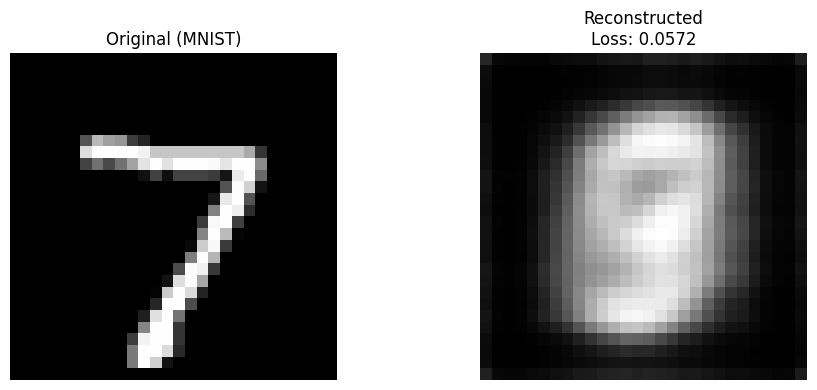

Processing CIFAR (Anomaly)...


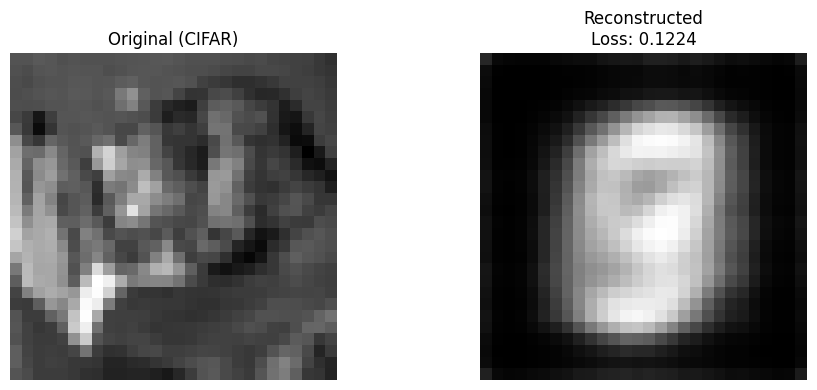

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

def manual_demo(index, dataset="MNIST"):
    # Select the image
    if dataset == "MNIST":
        img = x_test_mnist[index]
    else:
        img = x_test_cifar_processed[index]

    # Predict without the progress bar to prevent hanging
    recon = autoencoder.predict(img.reshape(1,28,28,1), verbose=0)

    # Calculate Loss
    loss = np.mean(np.square(img - recon))

    # Render Plot
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img.reshape(28,28), cmap='gray')
    plt.title(f"Original ({dataset})")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(recon.reshape(28,28), cmap='gray')
    plt.title(f"Reconstructed\nLoss: {loss:.4f}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the demos
print("Processing MNIST...")
manual_demo(0, "MNIST")

print("Processing CIFAR (Anomaly)...")
manual_demo(0, "CIFAR")

In [10]:
# Compare average loss
mnist_recon = autoencoder.predict(x_test_mnist[:100], verbose=0)
cifar_recon = autoencoder.predict(x_test_cifar_processed[:100], verbose=0)

mnist_loss = np.mean(np.square(x_test_mnist[:100] - mnist_recon))
cifar_loss = np.mean(np.square(x_test_cifar_processed[:100] - cifar_recon))

print(f"Average MNIST Loss (Normal): {mnist_loss:.4f}")
print(f"Average CIFAR Loss (Anomaly): {cifar_loss:.4f}")
print(f"Anomaly Detection Ratio: {cifar_loss / mnist_loss:.2f}x higher error!")

Average MNIST Loss (Normal): 0.0651
Average CIFAR Loss (Anomaly): 0.1939
Anomaly Detection Ratio: 2.98x higher error!
